# Assignment 4: Optimization with Parallelization
Group 15

- NG, Cheuk Nam (cnng@kth.se)
- WONG, Chun Him (chwon@kth.se)

# Exercise 1: Simulating Wildfire Spread Using Monte Carlo in Parallel

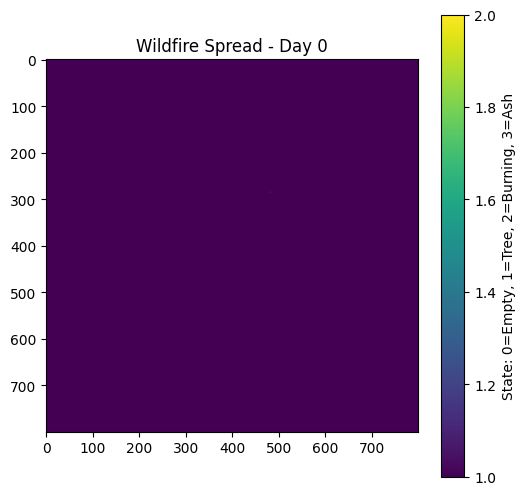

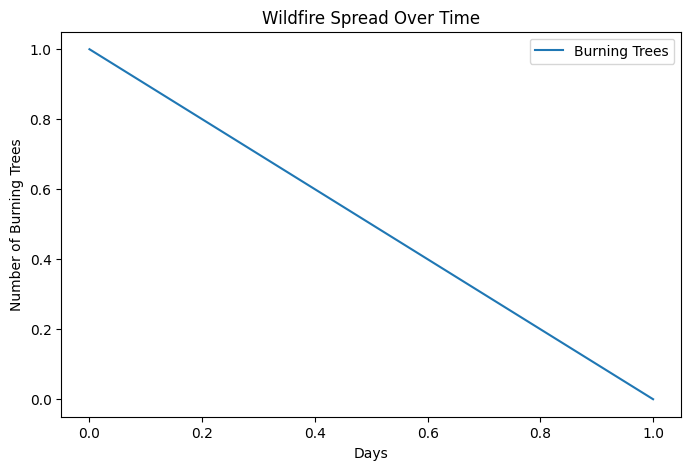

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Constants
GRID_SIZE = 800  # 800x800 forest grid
FIRE_SPREAD_PROB = 0.3  # Probability that fire spreads to a neighboring tree
BURN_TIME = 3  # Time before a tree turns into ash
DAYS = 60  # Maximum simulation time

# State definitions
EMPTY = 0    # No tree
TREE = 1     # Healthy tree 
BURNING = 2  # Burning tree 
ASH = 3      # Burned tree 

def initialize_forest():
    """Creates a forest grid with all trees and ignites one random tree."""
    forest = np.ones((GRID_SIZE, GRID_SIZE), dtype=int)  # All trees
    burn_time = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)  # Tracks how long a tree burns
    
    # Ignite a random tree
    x, y = random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)
    forest[x, y] = BURNING
    burn_time[x, y] = 1  # Fire starts burning
    
    return forest, burn_time

def get_neighbors(x, y):
    """Returns the neighboring coordinates of a cell in the grid."""
    neighbors = []
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # Up, Down, Left, Right
        nx, ny = x + dx, y + dy
        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
            neighbors.append((nx, ny))
    return neighbors

def simulate_wildfire():
    """Simulates wildfire spread over time."""
    forest, burn_time = initialize_forest()
    
    fire_spread = []  # Track number of burning trees each day
    
    for day in range(DAYS):
        new_forest = forest.copy()
        
        for x in range(GRID_SIZE):
            for y in range(GRID_SIZE):
                if forest[x, y] == BURNING:
                    burn_time[x, y] += 1  # Increase burn time
                    
                    # If burn time exceeds threshold, turn to ash
                    if burn_time[x, y] >= BURN_TIME:
                        new_forest[x, y] = ASH
                    
                    # Spread fire to neighbors
                    for nx, ny in get_neighbors(x, y):
                        if forest[nx, ny] == TREE and random.random() < FIRE_SPREAD_PROB:
                            new_forest[nx, ny] = BURNING
                            burn_time[nx, ny] = 1
        
        forest = new_forest.copy()
        fire_spread.append(np.sum(forest == BURNING))
        
        if np.sum(forest == BURNING) == 0:  # Stop if no more fire
            break
        
        # Plot grid every 5 days
        if day % 5 == 0 or day == DAYS - 1:
            plt.figure(figsize=(6, 6))
            plt.imshow(forest, cmap='viridis', origin='upper')
            plt.title(f"Wildfire Spread - Day {day}")
            plt.colorbar(label="State: 0=Empty, 1=Tree, 2=Burning, 3=Ash")
            plt.show()
    
    return fire_spread

# Run simulation
fire_spread_over_time = simulate_wildfire()

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(range(len(fire_spread_over_time)), fire_spread_over_time, label="Burning Trees")
plt.xlabel("Days")
plt.ylabel("Number of Burning Trees")
plt.title("Wildfire Spread Over Time")
plt.legend()
plt.show()

## Task 1.1: Parallelization with Multiprocessing

wildfire_sim_worker.py

In [8]:
import numpy as np
import random

# Constants (must match notebook)
GRID_SIZE = 800
FIRE_SPREAD_PROB = 0.3
BURN_TIME = 3
DAYS = 60
EMPTY, TREE, BURNING, ASH = 0, 1, 2, 3


def initialize_forest():
    forest = np.ones((GRID_SIZE, GRID_SIZE), dtype=int)
    burn_time = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    x, y = random.randint(0, GRID_SIZE - 1), random.randint(0, GRID_SIZE - 1)
    forest[x, y] = BURNING
    burn_time[x, y] = 1
    return forest, burn_time


def get_neighbors(x, y):
    neighbors = []
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nx, ny = x + dx, y + dy
        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
            neighbors.append((nx, ny))
    return neighbors


def run_one_simulation(_):
    """One wildfire run (no plotting). Returns list of burning-tree counts per day."""
    forest, burn_time = initialize_forest()
    fire_spread = []
    for day in range(DAYS):
        new_forest = forest.copy()
        for x in range(GRID_SIZE):
            for y in range(GRID_SIZE):
                if forest[x, y] == BURNING:
                    burn_time[x, y] += 1
                    if burn_time[x, y] >= BURN_TIME:
                        new_forest[x, y] = ASH
                    for nx, ny in get_neighbors(x, y):
                        if forest[nx, ny] == TREE and random.random() < FIRE_SPREAD_PROB:
                            new_forest[nx, ny] = BURNING
                            burn_time[nx, ny] = 1
        forest = new_forest.copy()
        fire_spread.append(int(np.sum(forest == BURNING)))
        if np.sum(forest == BURNING) == 0:
            break
    return fire_spread


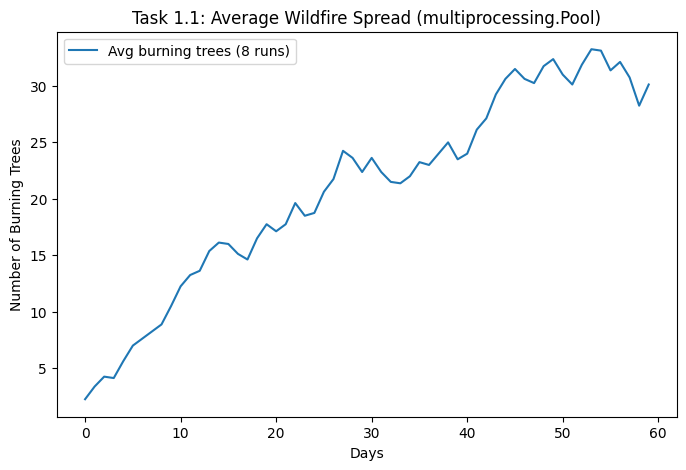

In [9]:
from multiprocessing import Pool, cpu_count
from wildfire_sim_worker import run_one_simulation  # worker in .py so Pool workers can import it

N_RUNS = 8  # number of independent simulations
n_workers = min(N_RUNS, cpu_count())

with Pool(processes=n_workers) as pool:
    results = pool.map(run_one_simulation, range(N_RUNS))

# Aggregate: average fire spread over time (pad shorter runs with 0)
max_len = max(len(r) for r in results)
padded = [np.array(r + [0] * (max_len - len(r)), dtype=float) for r in results]
avg_fire_spread = np.mean(padded, axis=0)

# Plot average fire spread
plt.figure(figsize=(8, 5))
plt.plot(range(len(avg_fire_spread)), avg_fire_spread, label="Avg burning trees ({} runs)".format(N_RUNS))
plt.xlabel("Days")
plt.ylabel("Number of Burning Trees")
plt.title("Task 1.1: Average Wildfire Spread (multiprocessing.Pool)")
plt.legend()
plt.show()


## Task1.2: Parallelization with Dask

Dask Dashboard: http://127.0.0.1:8787/status
→ Open this URL in your browser BEFORE the long computation, then go to the 'Task Stream' tab.
Computation submitted. Open the dashboard link above → 'Task Stream' or 'Tasks' tab to see the 8 simulations.


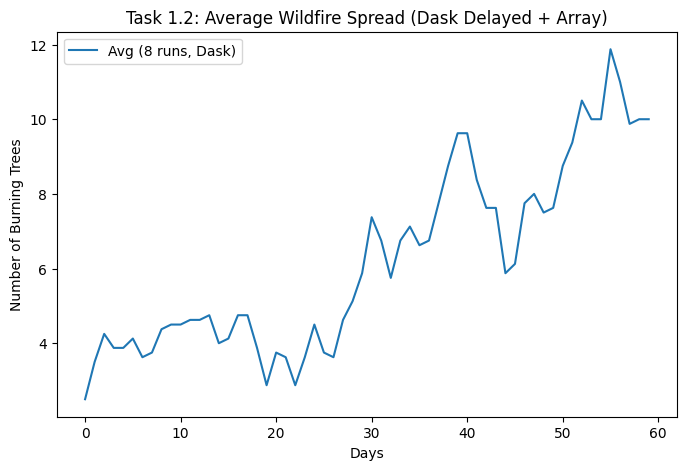

In [10]:
# Task 1.2: Parallelization with Dask (Delayed + Dask Array + distributed Client + Dashboard)
import dask
from dask import delayed
import dask.array as da
from dask.distributed import Client

# Start distributed client. Dashboard runs on localhost:8787 by default.
client = Client()
# Use this cluster for all Dask work (so the dashboard shows activity)
import dask.config
dask.config.set(scheduler=client)
print("Dask Dashboard:", client.dashboard_link)
print("→ Open this URL in your browser BEFORE the long computation, then go to the 'Task Stream' tab.")

# Wrapper: one simulation returning a fixed-length array (DAYS,) for Dask Array aggregation
def run_one_simulation_padded(_):
    from wildfire_sim_worker import run_one_simulation, DAYS
    import numpy as np
    r = run_one_simulation(_)
    return np.array(r + [0] * (DAYS - len(r)), dtype=np.float64)

N_RUNS = 8

# 1. Convert to Dask Delayed: each call is a lazy task
delayed_sims = [delayed(run_one_simulation_padded)(i) for i in range(N_RUNS)]

# 2. Convert results into a Dask Array (each delayed returns shape (DAYS,))
dask_arrays = [da.from_delayed(d, shape=(DAYS,), dtype=np.float64) for d in delayed_sims]
stacked = da.stack(dask_arrays)  # shape (N_RUNS, DAYS)

# 3. Aggregate with Dask Array: mean over runs, then compute
# Submit via client.compute() so tasks definitely run on the cluster and show on the dashboard
future = client.compute(da.mean(stacked, axis=0))
print("Computation submitted. Open the dashboard link above → 'Task Stream' or 'Tasks' tab to see the 8 simulations.")
avg_fire_spread = future.result()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(len(avg_fire_spread)), avg_fire_spread, label="Avg ({} runs, Dask)".format(N_RUNS))
plt.xlabel("Days")
plt.ylabel("Number of Burning Trees")
plt.title("Task 1.2: Average Wildfire Spread (Dask Delayed + Array)")
plt.legend()
plt.show()

client.close()

Dask Dashboard
![](asm4_task1.2.png)

## Task1.3: Performance Comparison

In [ ]:
import time
import numpy as np
from multiprocessing import Pool, cpu_count
from wildfire_sim_worker import run_one_simulation, DAYS

N_RUNS = 8
n_repeats = 2


def run_serial():
    results = [run_one_simulation(i) for i in range(N_RUNS)]
    return np.array([r + [0] * (DAYS - len(r)) for r in results], dtype=float).mean(axis=0)


def run_multiprocessing():
    n_workers = min(N_RUNS, cpu_count())
    with Pool(processes=n_workers) as pool:
        results = pool.map(run_one_simulation, range(N_RUNS))
    padded = [np.array(r + [0] * (DAYS - len(r)), dtype=float) for r in results]
    return np.mean(padded, axis=0)


def run_dask(n_workers=4, use_processes=True):
    try:
        from dask import delayed
        import dask.array as da
        from dask.distributed import Client, LocalCluster
    except ImportError:
        raise ImportError("Install dask and distributed: pip install dask distributed")

    def padded(_):
        from wildfire_sim_worker import run_one_simulation, DAYS
        import numpy as np
        r = run_one_simulation(_)
        return np.array(r + [0] * (DAYS - len(r)), dtype=np.float64)

    cluster = LocalCluster(processes=use_processes, n_workers=n_workers)
    client = Client(cluster)
    delayed_sims = [delayed(padded)(i) for i in range(N_RUNS)]
    dask_arrays = [da.from_delayed(d, shape=(DAYS,), dtype=np.float64) for d in delayed_sims]
    stacked = da.stack(dask_arrays)
    result = da.mean(stacked, axis=0).compute(scheduler=client)
    client.close()
    return result


def main():
    print("=" * 60)
    print("Task 1.3: Performance comparison (run outside Jupyter)")
    print("N_RUNS =", N_RUNS, "| n_repeats =", n_repeats)
    print("=" * 60)

    times = {}
    for name, fn in [
        ("Serial", run_serial),
        ("Multiprocessing", run_multiprocessing),
        ("Dask (4 workers)", lambda: run_dask(4)),
    ]:
        t_list = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            fn()
            t_list.append(time.perf_counter() - t0)
        times[name] = min(t_list)
        print(f"{name}: {times[name]:.2f} s (min of {n_repeats} runs)")

    print("\n--> Fastest:", min(times, key=times.get))


if __name__ == "__main__":
    main()



![](asm4_task1.3.png)

### Task 1.3 — Answers

1. **Which version is the fastest?**  
   According to the result above, **Multiprocessing** is fastest (parallel), and **Serial** is slowest (one core).

2. **How well does Dask scale with different numbers of workers?**  
   Time typically decreases as the number of workers increases (e.g. 1 → 2 → 4 → 8), up to a point where communication and overhead limit further speedup.
3. **How does chunk size affect performance?**  
   Fewer, larger tasks reduce scheduling overhead but can leave workers idle (worse load balance); more, smaller tasks improve load balance but add overhead. The best choice depends on run time per task and cluster size.

## Task 1.4: Visualization with ParaView and VTK

In [ ]:
import os
from wildfire_sim_worker import run_simulation_with_grids
from vtk_export import export_wildfire_to_vtk

VTK_GRID_SIZE = 100
VTK_MAX_DAYS = 40
OUT_DIR = "vtk_output"

grids = run_simulation_with_grids(grid_size=VTK_GRID_SIZE, max_days=VTK_MAX_DAYS)
paths = export_wildfire_to_vtk(grids, out_dir=OUT_DIR, prefix="forest")
print(f"Exported {len(paths)} VTK files to {OUT_DIR}/")
print(f"Files: {paths[0]} ... {paths[-1]}")
print("State: 1=Tree, 2=Burning, 3=Ash")

Exported 40 VTK files to vtk_output/
Files: vtk_output/forest_00000.vtk ... vtk_output/forest_00039.vtk
State: 1=Tree, 2=Burning, 3=Ash


### Snapshots of animation
![](asm4_task1.4_middle.png)
![](asm4_task1.4_finish.png)